In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

## StandardScaler (Estandarización)

La estandarización transforma las características para que tengan una media ($\mu$) de **0** y una desviación estándar ($\sigma$) de **1**. No cambia la forma de la distribución, pero redefine el origen y la escala.

* **Media ($\mu$):** Es el centro de masa de los datos. Al restarla ($x - \mu$), se realiza una **traslación** que centra los datos en el origen.
* **Desviación Estándar ($\sigma$):** Es la medida de dispersión. Al dividir por ella, se realiza un **escalamiento** que iguala la varianza en todas las variables.
* **Z-score ($z$):** El resultado indica a cuántas desviaciones estándar se encuentra un valor específico respecto al promedio.

### Implementación en Scikit-learn

En `sklearn.preprocessing.StandardScaler`, el proceso se ejecuta en dos fases técnicas:

1. **`fit()`**: El algoritmo calcula la media y la desviación estándar de cada columna del dataset de entrenamiento y las almacena internamente como atributos (`mean_`, `var_`).
2. **`transform()`**: Aplica la fórmula $z = (x - \mu) / \sigma$ a cada punto utilizando los valores calculados en el paso anterior.
3. **Resultado**: Devuelve una matriz de NumPy donde todas las características son comparables entre sí, eliminando la dominancia de variables con magnitudes grandes y acelerando la convergencia de optimizadores como el descenso de gradiente.

In [2]:
df_sams = pd.read_csv("sams_club.csv")
df_sams.head(5)

,Monto_Venta_MXN,Cantidad_Articulos,Ingreso_Anual_Socio,Gasto_Abarrotes_MXN,Gasto_Electronica_MXN
0,16238.50,24,104508.28,3900,10000
1,14016.07,17,66734.26,4500,5000
2,16766.91,78,80577.24,3000,10000
3,19830.60,86,134482.32,2100,5000
4,13680.46,8,352041.11,4500,5000


In [3]:
df_sams.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
Monto_Venta_MXN,1000.0,14567.662,3427.256,3155.56,12233.430,14588.555,16767.802,27984.56
Cantidad_Articulos,1000.0,62.416,33.150,5.00,33.000,64.000,90.250,119.00
Ingreso_Anual_Socio,1000.0,290345.389,490352.167,60002.09,115546.325,185353.805,317804.395,7513597.72
Gasto_Abarrotes_MXN,1000.0,3534.900,1026.843,900.00,2700.000,3600.000,4200.000,7200.00
Gasto_Electronica_MXN,1000.0,4907.500,3565.165,0.00,2500.000,5000.000,7500.000,17500.00


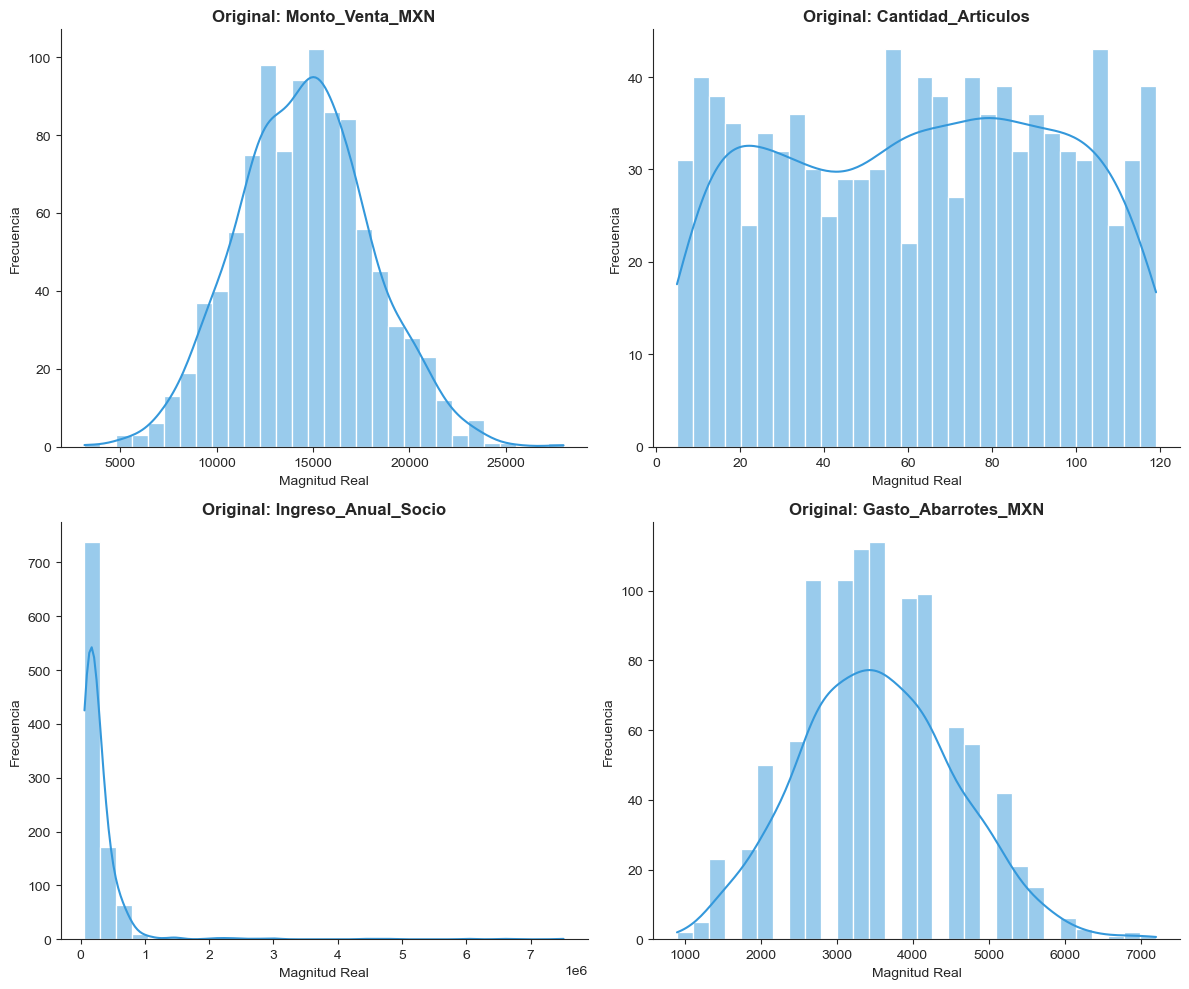

In [4]:
columnas_4 = ['Monto_Venta_MXN', 'Cantidad_Articulos', 'Ingreso_Anual_Socio', 'Gasto_Abarrotes_MXN']

sns.set_style("ticks")


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten() 

for i, col in enumerate(columnas_4):
    sns.histplot(df_sams[col], ax=axes[i], color='#3498db', kde=True, bins=30)
    axes[i].set_title(f'Original: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('Magnitud Real')
    
    
    axes[i].grid(False)

sns.despine()
plt.tight_layout()
plt.show()

In [5]:
scaler = StandardScaler()
X1 = scaler.fit_transform(df_sams)

In [6]:
df_sams_scaler = pd.DataFrame(X1, columns=df_sams.columns)

In [7]:
df_sams_scaler.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
Monto_Venta_MXN,1000.0,-0.0,1.001,-3.331,-0.681,0.006,0.642,3.917
Cantidad_Articulos,1000.0,0.0,1.001,-1.733,-0.888,0.048,0.840,1.708
Ingreso_Anual_Socio,1000.0,0.0,1.001,-0.470,-0.357,-0.214,0.056,14.738
Gasto_Abarrotes_MXN,1000.0,-0.0,1.001,-2.567,-0.813,0.063,0.648,3.571
Gasto_Electronica_MXN,1000.0,-0.0,1.001,-1.377,-0.676,0.026,0.728,3.534


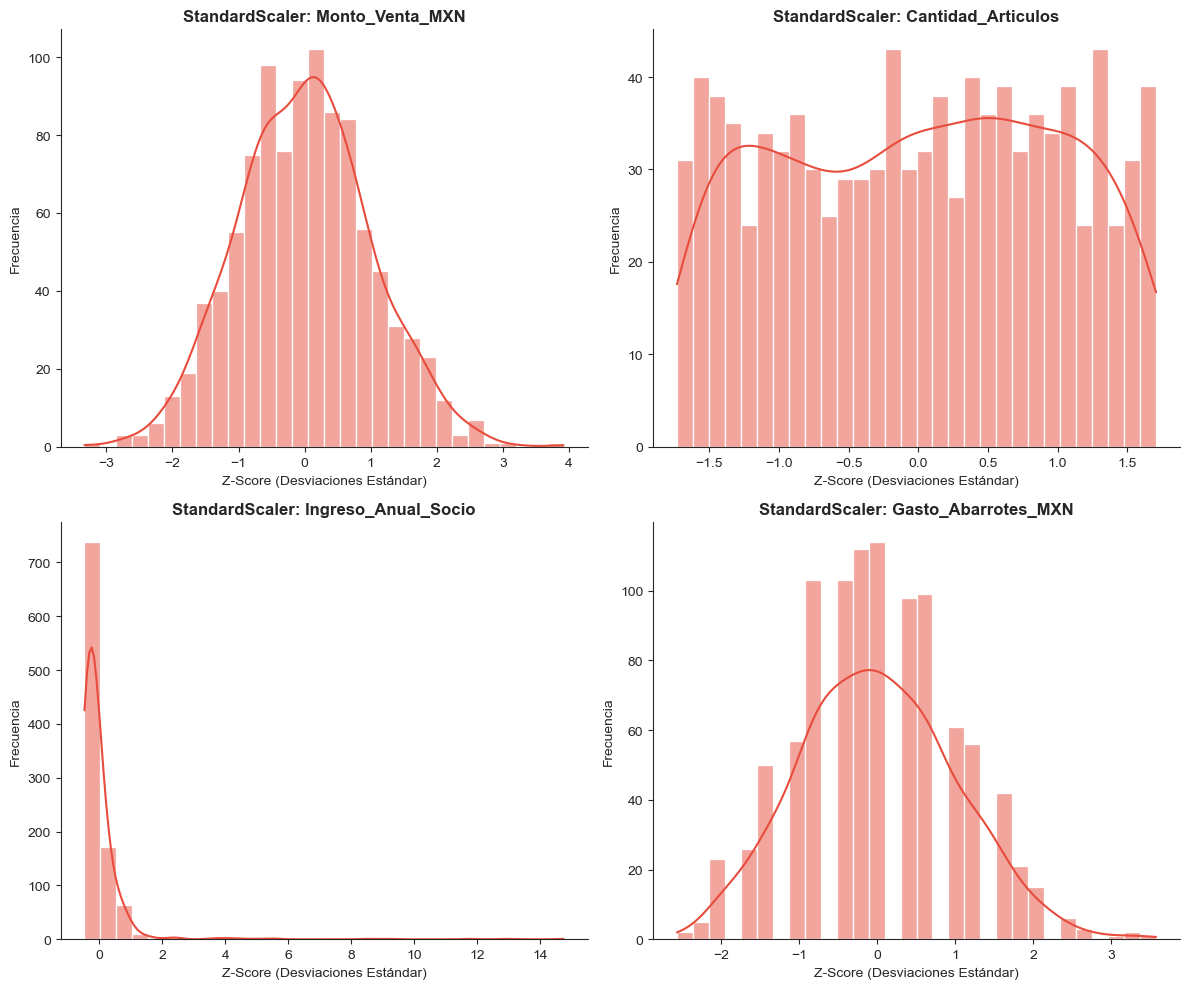

In [8]:
columnas_4 = ['Monto_Venta_MXN', 'Cantidad_Articulos', 'Ingreso_Anual_Socio', 'Gasto_Abarrotes_MXN']

sns.set_style("ticks")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_4):
    sns.histplot(df_sams_scaler[col], ax=axes[i], color='#e74c3c', kde=True, bins=30)
    axes[i].set_title(f'StandardScaler: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('Z-Score (Desviaciones Estándar)')
    axes[i].grid(False)

sns.despine()
plt.tight_layout()
plt.show()

## MinMaxScaler (Escalamiento a un Rango)

El escalamiento Min-Max transforma las características de forma lineal para comprimirlas o expandirlas dentro de un rango estrictamente acotado, comúnmente **[0, 1]**.

* **Numerador ($x - \min$):** Realiza una traslación que desplaza el valor más pequeño de la columna hasta el **0**.
* **Denominador ($\max - \min$):** Representa el rango total (amplitud) de los datos originales. Al dividir por este valor, se realiza un escalamiento que asegura que el valor máximo se convierta en **1**.
* **Sensibilidad:** A diferencia de la estandarización, este método es extremadamente sensible a **outliers** (valores atípicos). Si existe un valor extremadamente grande, el resto de los datos se comprimirá en un rango muy pequeño cercano a cero para poder mantener al outlier en 1.

### Implementación en Scikit-learn

En `sklearn.preprocessing.MinMaxScaler`, el proceso técnico opera de la siguiente manera:

1. **`fit()`**: El algoritmo identifica los valores mínimo (`data_min_`) y máximo (`data_max_`) presentes en cada columna del conjunto de datos.
2. **`transform()`**: Aplica la fórmula para proyectar los datos al rango deseado. Aunque el valor predeterminado es `(0, 1)`, el parámetro `feature_range` permite definir rangos personalizados, como `(-1, 1)`.
3. **Resultado**: Devuelve una matriz donde se preserva exactamente la forma de la distribución original y las distancias relativas entre puntos, pero todas las variables comparten límites idénticos. Es el método preferido para algoritmos que no asumen una distribución específica de los datos (como Redes Neuronales) o cuando se requiere que los valores sean estrictamente positivos.

In [9]:
scaleMinMax = MinMaxScaler(feature_range = (0,1))
X2 = scaleMinMax.fit_transform(df_sams)

df_sams_minmax = pd.DataFrame(X2,columns=df_sams.columns)
df_sams_minmax.head(5)


,Monto_Venta_MXN,Cantidad_Articulos,Ingreso_Anual_Socio,Gasto_Abarrotes_MXN,Gasto_Electronica_MXN
0,0.526922,0.166667,0.005971,0.476190,0.571429
1,0.437412,0.105263,0.000903,0.571429,0.285714
2,0.548204,0.640351,0.002760,0.333333,0.571429
3,0.671595,0.710526,0.009993,0.190476,0.285714
4,0.423895,0.026316,0.039181,0.571429,0.285714


In [10]:
df_sams_minmax.describe()

,Monto_Venta_MXN,Cantidad_Articulos,Ingreso_Anual_Socio,Gasto_Abarrotes_MXN,Gasto_Electronica_MXN
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.459628,0.503649,0.030904,0.418238,0.280429
std,0.138034,0.290794,0.065787,0.162991,0.203724
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.365616,0.245614,0.007452,0.285714,0.142857
50%,0.460469,0.517544,0.016818,0.428571,0.285714
75%,0.548240,0.747807,0.034588,0.523810,0.428571
max,1.000000,1.000000,1.000000,1.000000,1.000000


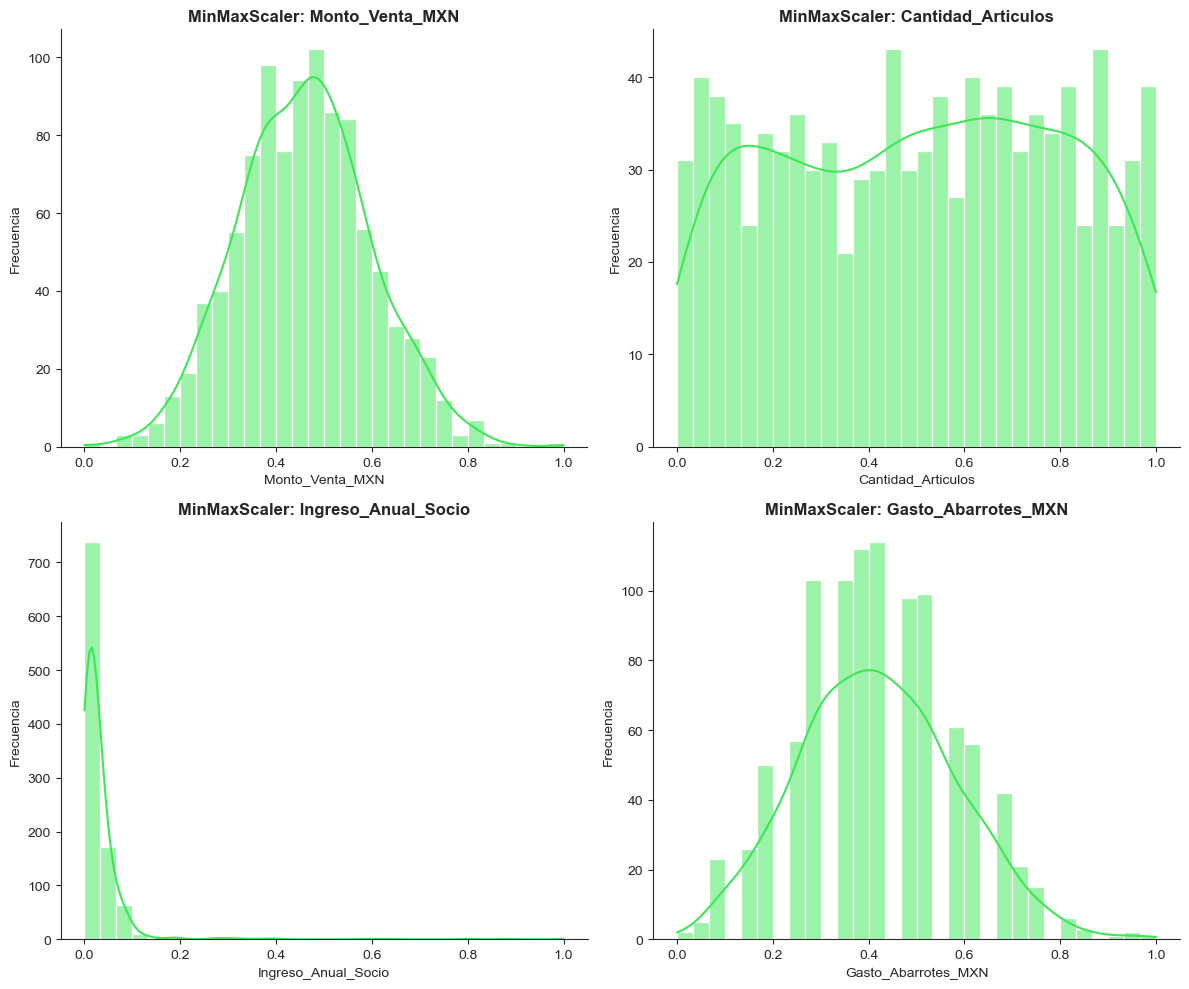

In [11]:
columnas_4 = ['Monto_Venta_MXN', 'Cantidad_Articulos', 'Ingreso_Anual_Socio', 'Gasto_Abarrotes_MXN']

sns.set_style("ticks")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_4):
    sns.histplot(df_sams_minmax[col], ax=axes[i], color="#3ce756", kde=True, bins=30)
    axes[i].set_title(f'MinMaxScaler: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(False)

sns.despine()
plt.tight_layout()
plt.show()